In [66]:
!pip install qiskit qiskit-aer pandas matplotlib pylatexenc sympy seaborn --break-system-packages

In [83]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector

from qiskit.transpiler import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
def W(n_qubits:int) -> QuantumCircuit:
    qc = QuantumCircuit(n_qubits, name="W")

    get_theta = lambda i : 2*np.acos(1/np.sqrt(i))

    base_value = n_qubits
    for qubit in range(0, n_qubits-1):
        if qubit == 0:
            qc.ry(get_theta(base_value), 0)
        else:
            qc.cry(get_theta(base_value), qubit-1, qubit)
        base_value -= 1

    for qubit in range(n_qubits-1, 0, -1):
        qc.cx(qubit-1,qubit)
    qc.x(0)

    return qc
    

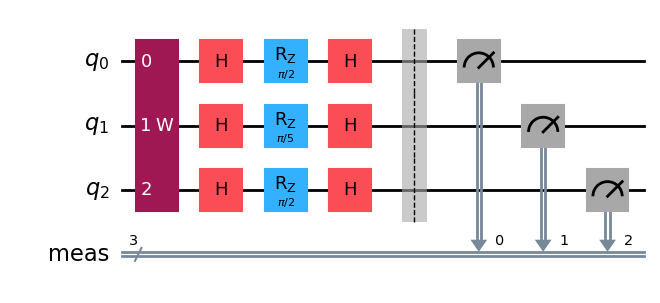

In [54]:
n_qubits = 3
qc = QuantumCircuit(n_qubits)
qc.append(W(n_qubits), range(n_qubits))
qc.h(range(n_qubits))
qc.rz(np.pi/2,0)
qc.rz(np.pi/5,1)
qc.rz(np.pi/2,2)
qc.h(range(n_qubits))
qc.measure_all()
display(qc.draw("mpl"))
#display(plot_bloch_multivector(qc))
#Statevector(qc).draw("latex")

In [108]:
def get_results(qc:QuantumCircuit, show:bool=True):
    sim = AerSimulator()
    sampler = SamplerV2()
    
    pm = generate_preset_pass_manager(optimization_level=2, backend=sim)
    qc_isa = pm.run([qc])[0]
    
    result = sampler.run([qc_isa], shots=10000).result()[0].data.meas.get_counts()
    if(show): 
        display(plot_histogram(result))
    return result

In [79]:
data = pd.DataFrame(columns=("result", "bit", "angle"))
i = 0
for angle in [0, np.pi/4, np.pi/2, np.pi/8]:
    qc = QuantumCircuit(1)
    qc.id(0)
    qc.barrier()
    qc.h(0)
    qc.rz(angle,0)
    qc.h(0)
    qc.measure_all()

    results = get_results(qc, show=False)
    data.loc[i] = {"result":results.get("0",0), "bit":"0", "angle":angle} 
    data.loc[i+1] = {"result":results.get("1",0), "bit":"1", "angle":angle}
    i += 2

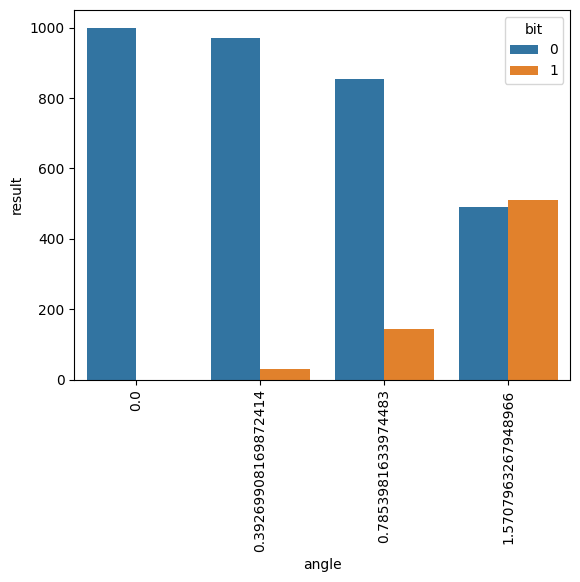

In [85]:
sns.barplot(data=data, y="result", hue="bit", x="angle")
plt.xticks(rotation=90)
plt.show()

In [86]:
data = pd.DataFrame(columns=("result", "bit", "angle"))
i = 0
for angle in [0, np.pi/4, np.pi/2, np.pi/8]:
    qc = QuantumCircuit(1)
    qc.x(0)
    qc.barrier()
    qc.h(0)
    qc.rz(angle,0)
    qc.h(0)
    qc.measure_all()

    results = get_results(qc, show=False)
    data.loc[i] = {"result":results.get("0",0), "bit":"0", "angle":angle} 
    data.loc[i+1] = {"result":results.get("1",0), "bit":"1", "angle":angle}
    i += 2

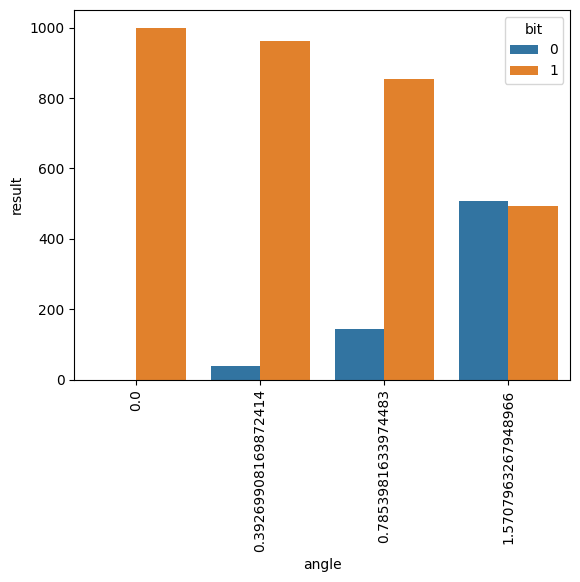

In [87]:
sns.barplot(data=data, y="result", hue="bit", x="angle")
plt.xticks(rotation=90)
plt.show()

Após criar um estado em que um dos jogadores (qubits) está com o anel, todos os valores são colocados em X e então a ideia é que os jogadores consigam dizer quem está com o anel usando rotações de um set $R$ que o arbitro forneceu e um número de jogadas $j$. A ideia é tentar avaliar como isso pode ser feito de forma individual e explorando entanglement




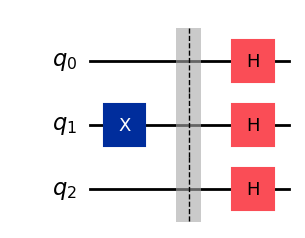

In [89]:
qc = QuantumCircuit(3)
qc.x(1)
qc.barrier()
qc.h(range(3))
qc.rz(np.pi/

qc.draw("mpl")

O jogo consiste em partes:

1. $W$ state definindo quem está com o anel
2. aplica-se $H^{\otimes n}$
3. aqui são intercaladas jogadas e troca de informação (aqui a ideia é quem está com o anel esconder sua fase em relação com quem irá se conectar)

regras:
* todos precisam jogar uma rotação

In [145]:
qc = QuantumCircuit(2)
qc.x(1)
qc.barrier()
qc.h(range(2))
qc.rz(np.pi/8,range(2))
qc.cx(0,1)
qc.h(range(2))
qc.measure_all()
#display(qc.draw("mpl"))
#display(Statevector(qc).draw("latex"))
#display(plot_bloch_multivector(qc))

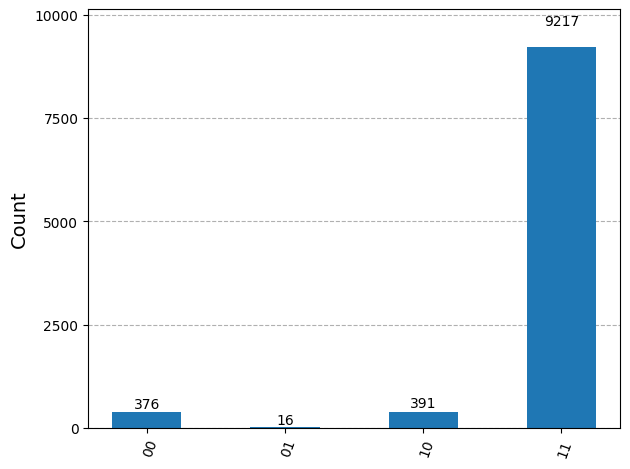

{'11': 9217, '00': 376, '10': 391, '01': 16}

In [146]:
get_results(qc)